In [1]:
# Dirichlet‑Process clustering of NDVI time series
# Piece‑wise (Loredo‑style) temporal model
# PyMC implementation with truncated DP and sequential updating

import numpy as np
import pymc as pm
import pytensor.tensor as pt
from matplotlib import pyplot as plt

import scipy.stats as stats

In [46]:
# ============================================================
# USER PARAMETERS
# ============================================================
MAX_CLUSTERS = 4          # truncation level of DP
N_SEGMENTS   = 23          # piece‑wise bins for temporal model (e.g. 23 for 16‑day NDVI)
ALPHA_DP     = 3.0         # DP concentration
SIGMA_MODIS  = 0.02        # NDVI noise (~MODIS typical)

In [47]:
# ============================================================
# UTILITIES
# ============================================================

def doy_to_bin(doy, n_segments=N_SEGMENTS):
    """Map day-of-year to piecewise bin"""
    return np.floor((doy % 365) / 365 * n_segments).astype(int)

In [ ]:
def build_model_multi(series_bins, series_values):
    """
    series_bins : list of arrays of bins per series
    series_values: list of NDVI arrays
    """

    n_series = len(series_values)

    with pm.Model() as model:
        # ---------- Stick‑breaking DP ----------
        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)
        pi = pm.Deterministic("pi", pm.math.concatenate([beta[0:1], beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]))
        pi = pi / pm.math.sum(pi)

        # ---------- Piecewise NDVI per cluster ----------
        a = pm.Uniform("a", lower=0, upper=1.0, shape=(MAX_CLUSTERS, N_SEGMENTS))
        # sigma = pm.HalfNormal("sigma", SIGMA_MODIS)

        # ---------- Cluster assignment per SERIES ----------
        z = pm.Categorical("z", p=pi, shape=n_series)

        # ---------- Likelihood per series ----------
        for i in range(n_series):
            mu_i = a[z[i], series_bins[i]]
            # pm.Normal(f"y_{i}", mu=mu_i, sigma=sigma,
            pm.Normal(f"y_{i}", mu=mu_i, sigma=SIGMA_MODIS,
            observed=series_values[i])

    return model


In [ ]:
def build_model_multi_hierar(series_bins, series_values):
    """
    series_bins : list of arrays of bins per series
    series_values: list of NDVI arrays
    """

    n_series = len(series_values)

    with pm.Model() as model:
        # ---------- Stick‑breaking DP ----------
        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)
        pi = pm.Deterministic("pi", pm.math.concatenate([beta[0:1], beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]))
        pi = pi / pm.math.sum(pi)

        # ---------- Piecewise NDVI per cluster ----------
        # version uniforme
        # a = pm.Uniform("a", lower=0, upper=1.0, shape=(MAX_CLUSTERS, N_SEGMENTS))

        # version jerárquica
        # mu0 = pm.Normal("mu0", 0.4, 0.2, shape=N_SEGMENTS)
        # tau = pm.HalfNormal("tau", 0.1)

        # version jerárquica autotune
        # global_mean = series_values.mean()
        # global_std  = series_values.std()
        # mu0 = pm.Normal("mu0", global_mean, global_std, shape=N_SEGMENTS)
        # tau = pm.HalfNormal("tau", global_std/2)

        # Hiperprior jerárquico completo
        mu_global = pm.Normal("mu_global", 0.4, 0.3)
        sigma_global = pm.HalfNormal("sigma_global", 0.3)

        mu0 = pm.Normal("mu0", mu_global, sigma_global, shape=N_SEGMENTS)

        # tau_scale = pm.HalfNormal("tau_scale", 0.3)
        # tau = pm.HalfNormal("tau", tau_scale)
        tau = pm.HalfNormal("tau", SIGMA_MODIS)

        a = pm.Normal("a", mu0, tau, shape=(MAX_CLUSTERS, N_SEGMENTS))
        # sigma = pm.HalfNormal("sigma", SIGMA_MODIS)

        # ---------- Cluster assignment per SERIES ----------
        z = pm.Categorical("z", p=pi, shape=n_series)

        # ---------- Likelihood per series ----------
        for i in range(n_series):
            mu_i = a[z[i], series_bins[i]]
            # pm.Normal(f"y_{i}", mu=mu_i, sigma=sigma,
            pm.Normal(f"y_{i}", mu=mu_i, sigma=SIGMA_MODIS,
            observed=series_values[i])

    return model


In [48]:
def build_model_multi_hierar_RW(series_bins, series_values):
    """
    series_bins : list of arrays of bins per series
    series_values: list of NDVI arrays
    """

    n_series = len(series_values)

    with pm.Model() as model:

        # =========================
        # Stick-breaking DP
        # =========================
        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pm.math.concatenate(
                [
                    beta[0:1],
                    beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])
                ]
            )
        )
        pi = pi / pm.math.sum(pi)

        # =========================
        # Hiperprior jerárquico global
        # =========================
        mu_global = pm.Normal("mu_global", 0.4, 0.3)
        sigma_global = pm.HalfNormal("sigma_global", 0.3)

        mu0 = pm.Normal("mu0", mu_global, sigma_global, shape=MAX_CLUSTERS)

        # tau_scale = pm.HalfNormal("tau_scale", 0.2)
        tau_init = pm.HalfNormal("tau_init", SIGMA_MODIS)

        # =========================
        # Nivel inicial del Random Walk
        # =========================
        a0 = pm.Normal("a0", mu0, tau_init, shape=MAX_CLUSTERS)

        # =========================
        # Incrementos temporales (asimétricos)
        # =========================
        # b controla suavidad general
        # kappa > 1 penaliza más ascensos que descensos
        b = pm.HalfNormal("b_rw", 0.05)
        kappa = pm.HalfNormal("kappa_rw", 2.0)

        delta = pm.AsymmetricLaplace(
            "delta",
            mu=0.0,
            b=b,
            kappa=kappa,
            shape=(MAX_CLUSTERS, N_SEGMENTS - 1)
        )

        # =========================
        # Construcción acumulativa
        # =========================
        a = pm.Deterministic(
            "a",
            pt.concatenate(
                [
                    a0[:, None],
                    a0[:, None] + pt.cumsum(delta, axis=1)
                ],
                axis=1
            )
        )

        # =========================
        # Asignación de cluster por serie
        # =========================
        z = pm.Categorical("z", p=pi, shape=n_series)

        # =========================
        # Likelihood por serie
        # =========================
        for i in range(n_series):
            mu_i = a[z[i], series_bins[i]]

            pm.Normal(
                f"y_{i}",
                mu=mu_i,
                sigma=SIGMA_MODIS,
                observed=series_values[i],
            )

    return model

### levanto series NDVI

In [5]:
import pandas as pd

In [6]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [7]:
nSeries = 100

In [8]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

### reconstruyo vector fechas

In [9]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [10]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [11]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [13]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [14]:
ndviDataStart+=1

In [15]:
fechas.shape

(430,)

In [16]:
ndviDataStart

8

/tmp/ipykernel_55454/4274161803.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_55454/4274161803.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout


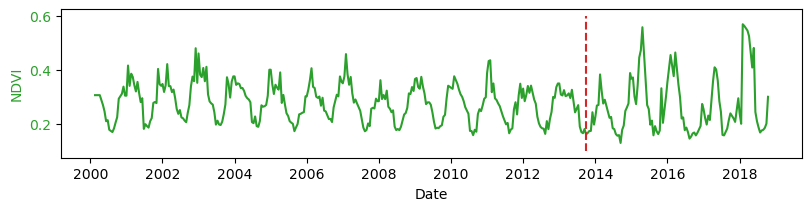

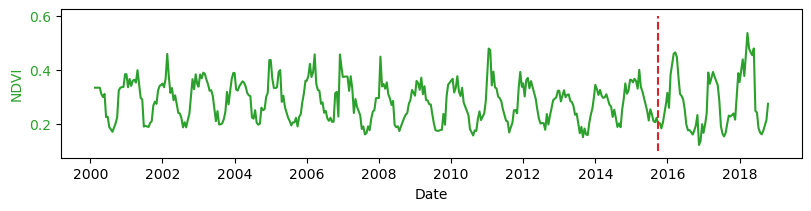

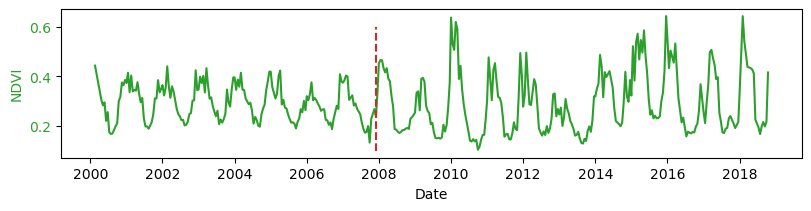

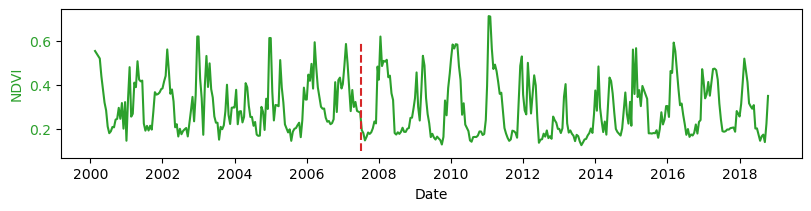

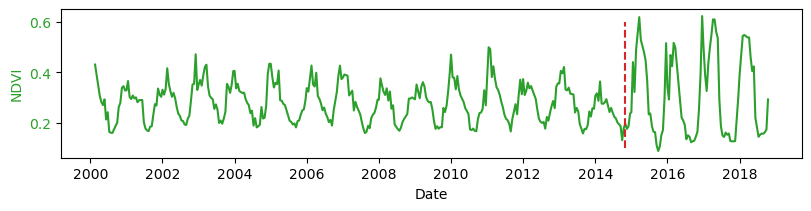

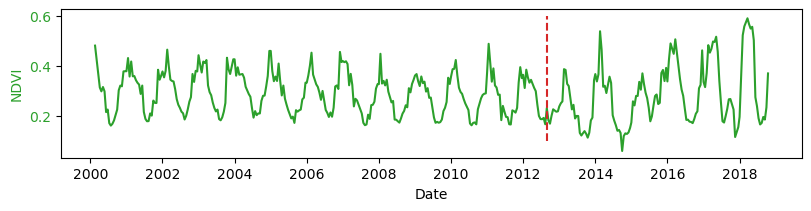

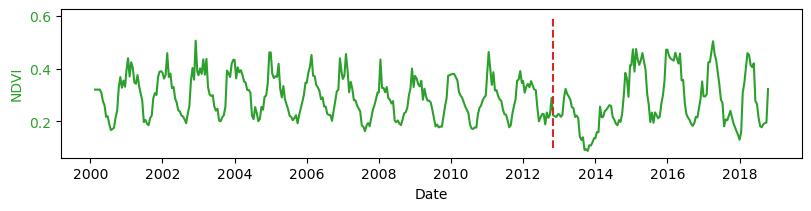

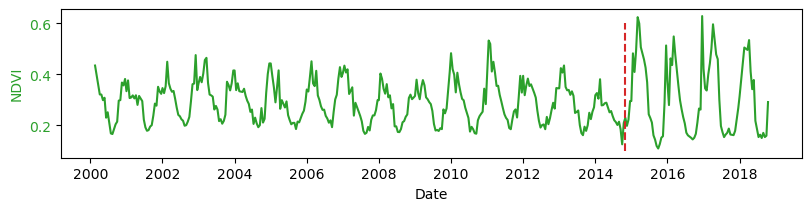

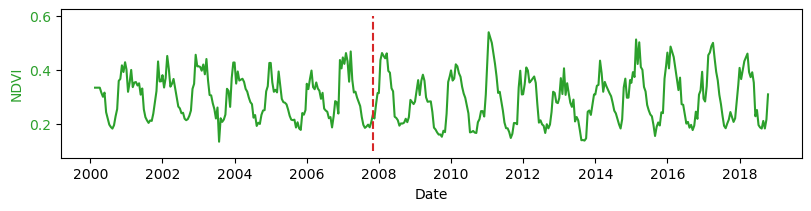

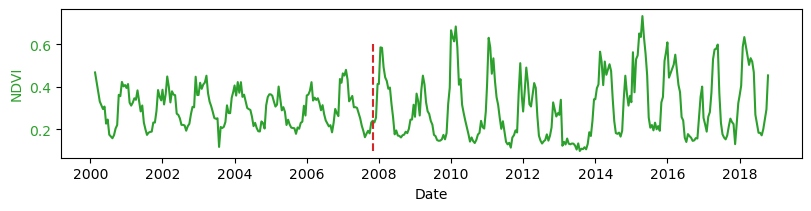

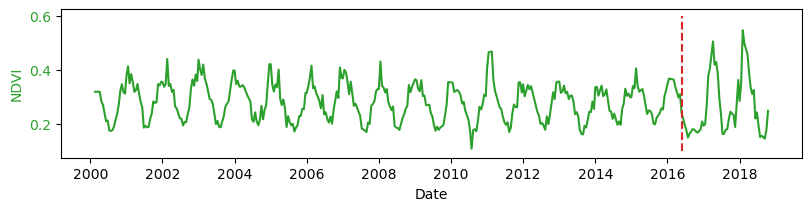

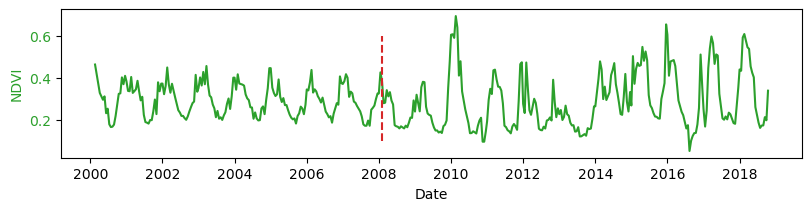

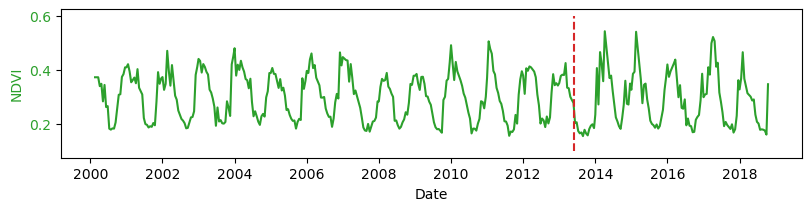

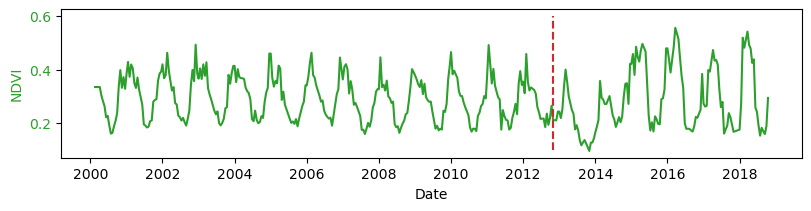

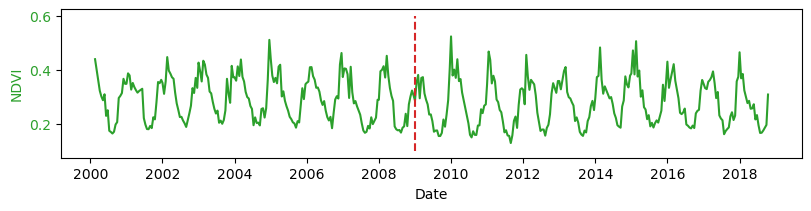

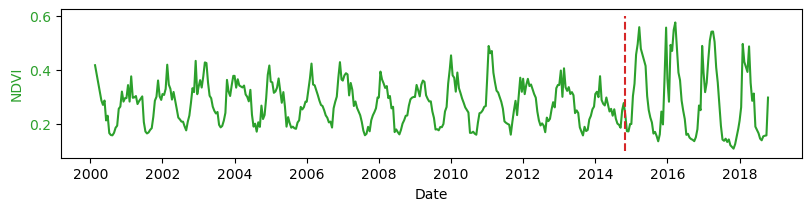

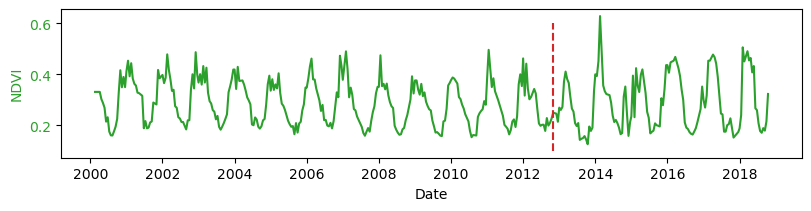

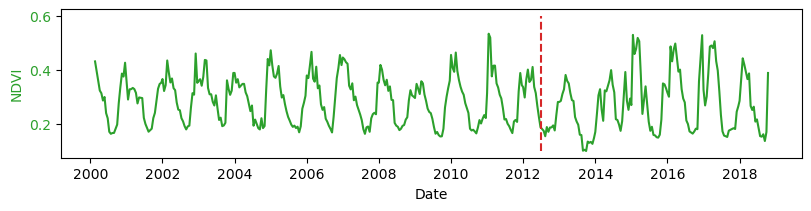

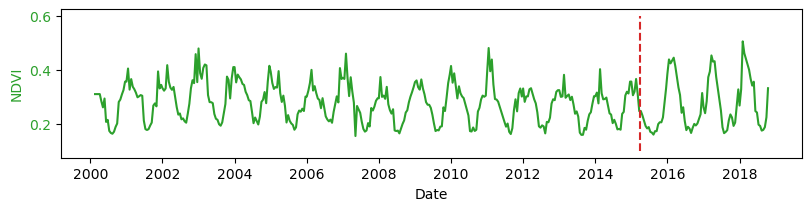

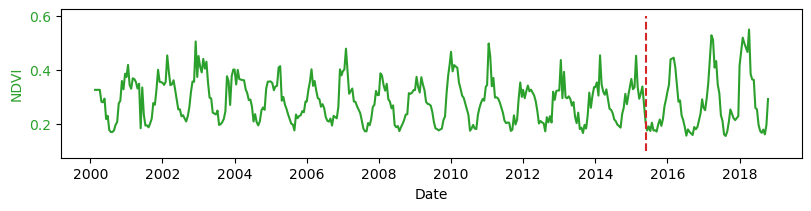

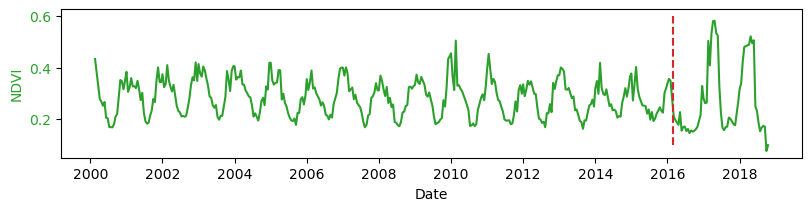

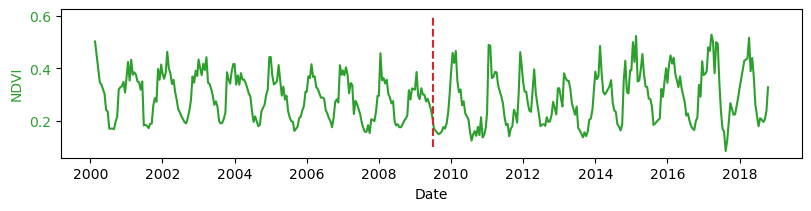

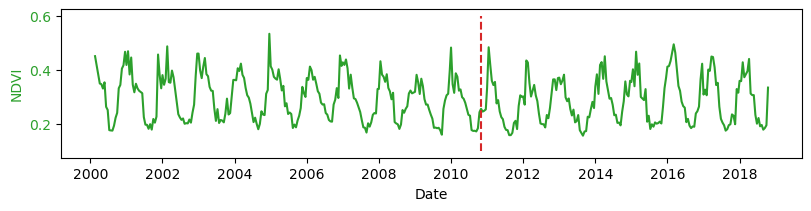

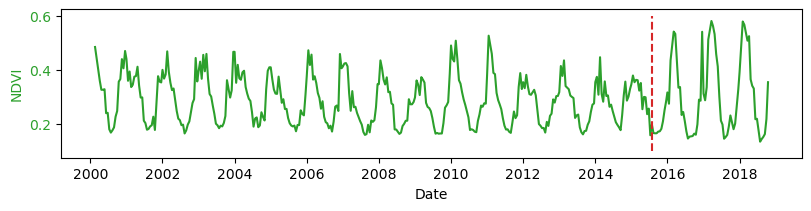

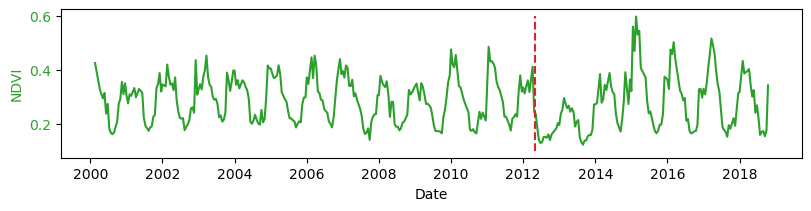

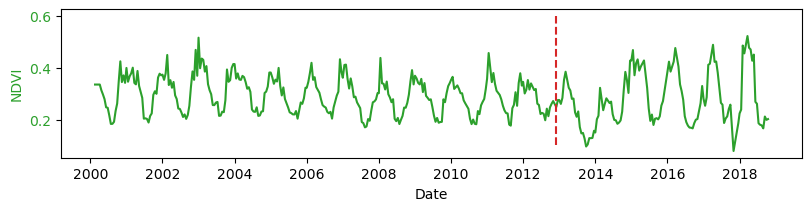

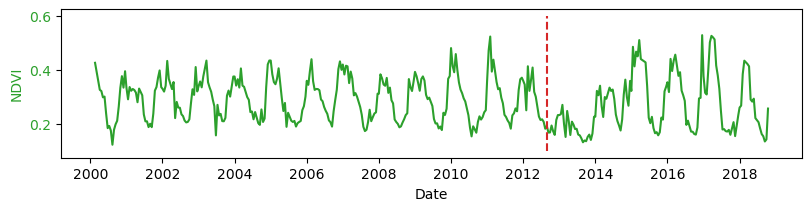

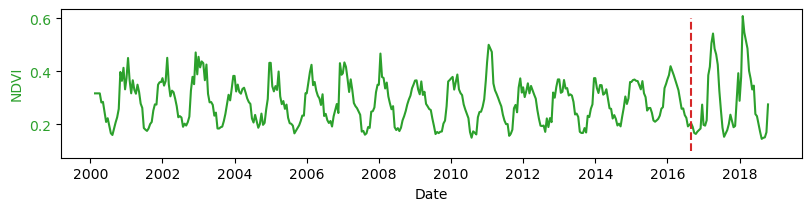

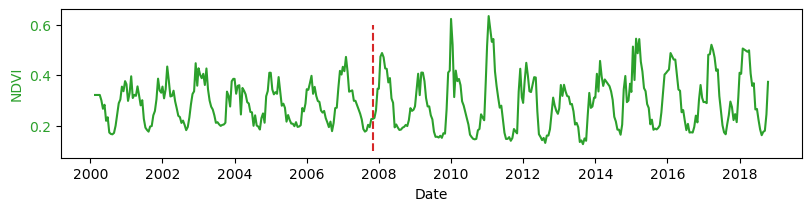

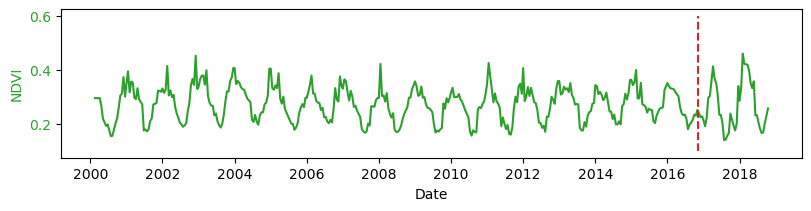

In [54]:
for pixel in testPixel[:30]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    color2 = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, ndvi, color=color1)
    ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
    ax1.tick_params(axis='y', labelcolor=color1)

    fig.show()

### Separo bosque no bosque temporal!

In [18]:
pixel = testPixel[0]
deforestationDate = df['fechaDef'].iloc[pixel]
ndvi = df.iloc[pixel, ndviDataStart-1:].values

In [19]:
deforestationDate.to_julian_date()

2456566.5

In [20]:
fechas.to_julian_date()

Index([2451592.5, 2451608.5, 2451624.5, 2451640.5, 2451656.5, 2451672.5,
       2451688.5, 2451704.5, 2451720.5, 2451736.5,
       ...
       2458263.5, 2458279.5, 2458295.5, 2458311.5, 2458327.5, 2458343.5,
       2458359.5, 2458375.5, 2458391.5, 2458407.5],
      dtype='float64', length=430)

In [22]:
nSeriesToTrain = 30

In [23]:
series = []

ANIOS_ENTRENAMIENTO = 3

for pixel in testPixel[:nSeriesToTrain]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    # defIndex = np.argmax(fechas == deforestationDate)
    defIndex = np.argmin(np.abs(fechas.to_julian_date() - deforestationDate.to_julian_date()))
    
    firstJanIndex = np.argmax(fechas[defIndex:].month == 1) + defIndex #indice del primer enero después de la deforestación
    lastJanIndex = defIndex - np.argmax(np.flip(fechas[:defIndex].month == 1)) -1 #indice del ultimo enero antes de la deforestación

    # bosque = df.iloc[pixel, ndviDataStart-1:defIndex].values # todo el bosque
    bosque = df.iloc[pixel, lastJanIndex-(N_SEGMENTS*ANIOS_ENTRENAMIENTO):lastJanIndex].values # solo los tres años antes de la deforestación
    noBosque = df.iloc[pixel, firstJanIndex:firstJanIndex+(N_SEGMENTS*ANIOS_ENTRENAMIENTO)].values #segmento de tres años primer enero después de la deforestación

    if len(noBosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos después de la deforestación para el pixel {pixel}.")
        continue

    if len(bosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos antes de la deforestación para el pixel {pixel}.")
        continue
    
    if False:
        fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    series.append(bosque)
    series.append(noBosque)

    if False:
        color1 = 'tab:green'
        color2 = 'tab:red'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('NDVI', color=color1)
        ax1.plot(bosque, color=color1)
        ax1.plot(noBosque, color=color2)
        # ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
        ax1.tick_params(axis='y', labelcolor=color1)

        fig.show()

Advertencia: no hay suficientes datos después de la deforestación para el pixel 773.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 678.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 415.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 445.


In [24]:
quincenas = np.arange(0, 23*3)

In [25]:
quincenas.shape

(69,)

In [26]:
series = np.array(series)

In [27]:
series.shape

(52, 69)

In [28]:
#quincenas, series, true_clusters = synthetic_series(n_series=30, anios=3, sigma=SIGMA_MODIS)

In [29]:
# true_clusters 
true_clusters = [x%2 for x in range(series.shape[0])]

Text(0.5, 1.0, 'Series reales con clusters conocidos')

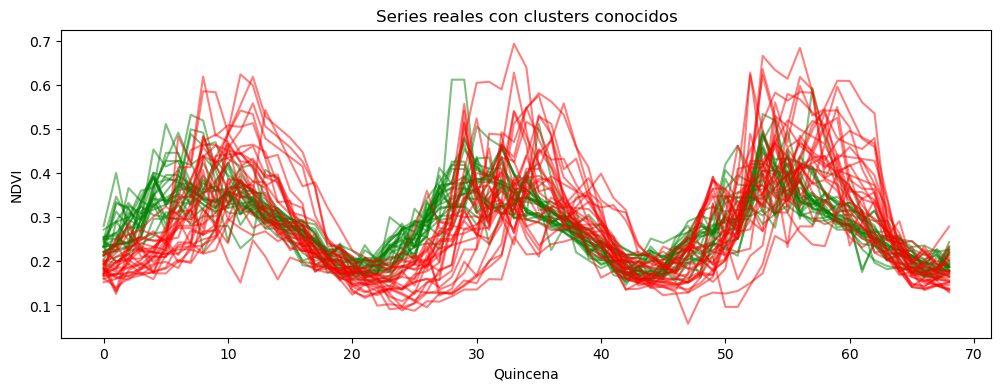

In [30]:
fig = plt.figure(figsize=(12,4))

plt.plot(quincenas, series[0::2, :].T, color='green', alpha=0.5)
plt.plot(quincenas, series[1::2, :].T, color='red', alpha=0.5)
plt.xlabel("Quincena")
plt.ylabel("NDVI")
plt.title("Series reales con clusters conocidos")

In [31]:
series = np.asarray(series, dtype=np.float32)

In [32]:
np.isnan(series).sum()

0

### version avanzada inicializacion de clusters

In [ ]:
from scipy.stats import norm

def crp_init(series_values, alpha, max_clusters, sigma, n_segments):
    """
    Inicialización estilo Chinese Restaurant Process
    compatible con DP piece-wise
    """

    n_series = len(series_values)
    order = np.random.permutation(n_series)

    z = -np.ones(n_series, dtype=int)
    clusters = []

    for i in order:
        s = series_values[i]

        probs = []

        # --- clusters existentes ---
        for k, members in enumerate(clusters):
            nk = len(members)

            mean_curve = np.mean([series_values[j] for j in members], axis=0)

            ll = np.sum(norm.logpdf(s, mean_curve, sigma))
            probs.append(np.log(nk) + ll)

        # --- cluster nuevo ---
        ll_new = np.sum(norm.logpdf(s, np.mean(s), sigma))
        probs.append(np.log(alpha) + ll_new)

        probs = np.exp(probs - np.max(probs))
        probs /= probs.sum()

        k_new = np.random.choice(len(probs), p=probs)

        if k_new == len(clusters):
            clusters.append([i])
            z[i] = k_new
        else:
            clusters[k_new].append(i)
            z[i] = k_new

        if len(clusters) >= max_clusters:
            break

    # llenar no asignados
    z[z < 0] = 0
    return z

### Inferencia

In [ ]:
np.random.seed(0)

# z_init = crp_init(
#     series_values=series,
#     alpha=ALPHA_DP,
#     max_clusters=MAX_CLUSTERS,
#     sigma=SIGMA_MODIS,
#     n_segments=N_SEGMENTS
# )

# quincenas, series, true_clusters = synthetic_series(n_series=30, anios=3)
# series_bins = [doy_to_bin(quincenas) for _ in series]
# series_bins = [quincenas for _ in series]
series_bins = [np.arange(len(s)) % 23 for s in series]
# model = build_model_multi(series_bins, series)
model = build_model_multi_hierar(series_bins, series)
# model = build_model_multi_hierar_RW(series_bins, series)

# with model:
#     trace = pm.sample(draws=5000, tune=1000, chains=4)
#     z_post = trace.posterior["z"].mean(dim=("chain","draw")).values
#     z_est = np.round(z_post).astype(int)

with model:
    trace = pm.sample(draws=1000, 
                      tune=500, 
                      chains=4, 
                      target_accept=0.9)
                    #   initvals=[{"z": z_init} for _ in range(4)])

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 692 seconds.
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 342 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.

In [50]:
# model.free_RVs

for rv in model.free_RVs:
    print(rv.name, rv.eval().shape)

beta (4,)
mu_global ()
sigma_global ()
mu0 (4,)
tau_init ()
a0 (4,)
b_rw ()
kappa_rw ()
delta (4, 22)
z (52,)


In [51]:
z_samples = trace.posterior["z"].stack(samples=("chain","draw")).values
z_est = stats.mode(z_samples, axis=1, keepdims=False).mode

print("True clusters:")
print(true_clusters)
print("Estimated clusters:")
print(z_est)
print("Estimated N:", len(np.unique(z_est)))

True clusters:
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Estimated clusters:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Estimated N: 1


### Evaluacion convergencia

In [52]:
trace.posterior

<xarray.Dataset> Size: 8MB
Dimensions:       (chain: 4, draw: 1000, mu0_dim_0: 4, a0_dim_0: 4,
                   delta_dim_0: 4, delta_dim_1: 22, z_dim_0: 52, beta_dim_0: 4,
                   pi_dim_0: 4, a_dim_0: 4, a_dim_1: 23)
Coordinates:
  * chain         (chain) int64 32B 0 1 2 3
  * draw          (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * mu0_dim_0     (mu0_dim_0) int64 32B 0 1 2 3
  * a0_dim_0      (a0_dim_0) int64 32B 0 1 2 3
  * delta_dim_0   (delta_dim_0) int64 32B 0 1 2 3
  * delta_dim_1   (delta_dim_1) int64 176B 0 1 2 3 4 5 6 ... 16 17 18 19 20 21
  * z_dim_0       (z_dim_0) int64 416B 0 1 2 3 4 5 6 7 ... 45 46 47 48 49 50 51
  * beta_dim_0    (beta_dim_0) int64 32B 0 1 2 3
  * pi_dim_0      (pi_dim_0) int64 32B 0 1 2 3
  * a_dim_0       (a_dim_0) int64 32B 0 1 2 3
  * a_dim_1       (a_dim_1) int64 184B 0 1 2 3 4 5 6 7 ... 16 17 18 19 20 21 22
Data variables:
    mu_global     (chain, draw) float64 32kB 0.384 0.2628 0.3 ... 0.1823 0.2533
    mu0           (chain, draw, mu0_dim_0) float64 128kB 0.1877 ... 0.02399
    a0            (chain, draw, a0_dim_0) float64 128kB 0.1931 ... 0.01684
    delta         (chain, draw, delta_dim_0, delta_dim_1) float64 3MB 0.01811...
    z             (chain, draw, z_dim_0) int64 2MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    beta          (chain, draw, beta_dim_0) float64 128kB 0.8817 ... 0.09911
    sigma_global  (chain, draw) float64 32kB 0.42 0.2609 0.1761 ... 0.181 0.234
    tau_init      (chain, draw) float64 32kB 0.021 0.01797 ... 0.01924 0.01967
    b_rw          (chain, draw) float64 32kB 0.1641 0.1573 ... 0.2636 0.3043
    kappa_rw      (chain, draw) float64 32kB 2.321 2.365 2.185 ... 1.285 1.088
    pi            (chain, draw, pi_dim_0) float64 128kB 0.8817 ... 0.0009008
    a             (chain, draw, a_dim_0, a_dim_1) float64 3MB 0.1931 ... 5.106
Attributes:
    created_at:                 2026-03-03T19:57:16.303399+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.12.0
    sampling_time:              691.9587624073029
    tuning_steps:               500

In [53]:
import arviz as az
# az.summary(trace, var_names=["z"])
az.summary(trace)

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,0.256,0.180,-0.053,0.651,0.008,0.007,552.0,670.0,1.01
mu0[0],0.195,0.023,0.150,0.244,0.001,0.001,649.0,660.0,1.02
mu0[1],0.256,0.336,-0.271,1.093,0.014,0.017,585.0,584.0,1.01
mu0[2],0.258,0.317,-0.303,0.923,0.014,0.016,534.0,721.0,1.01
mu0[3],0.262,0.319,-0.303,0.940,0.014,0.017,548.0,676.0,1.01
...,...,...,...,...,...,...,...,...,...
"a[3, 18]",-56.341,86.536,-204.708,85.316,35.437,25.359,7.0,12.0,1.57
"a[3, 19]",-66.149,98.975,-245.879,82.245,42.447,28.492,7.0,11.0,1.62
"a[3, 20]",-68.305,103.347,-250.993,93.473,44.283,31.351,7.0,11.0,1.63
"a[3, 21]",-69.858,105.474,-253.440,97.912,44.987,31.362,7.0,11.0,1.62


In [38]:
trace.posterior["pi"].mean(dim=("chain","draw")).values

array([0.97693311, 0.00986822, 0.005024  , 0.00289534])

### Evaluacion clusters

In [39]:
# import numpy as np
# import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def aligned_confusion(true_labels, est_labels):
    true_labels = np.array(true_labels)
    est_labels  = np.array(est_labels)

    cm = confusion_matrix(true_labels, est_labels)

    # Hungarian algorithm → maximizar diagonal
    row_ind, col_ind = linear_sum_assignment(-cm)

    aligned_cm = cm[:, col_ind]
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

    aligned_est = np.array([mapping[e] for e in est_labels])

    return aligned_cm, aligned_est, mapping


In [40]:
def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Estimated cluster")
    plt.ylabel("True cluster")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j],
                     ha="center", va="center",
                     fontsize=12)

    plt.tight_layout()
    plt.show()


In [41]:
uniques = np.unique(z_est)

In [ ]:
z_est[z_est == 4] = 3

Cluster mapping: {0: 0, 1: 1}


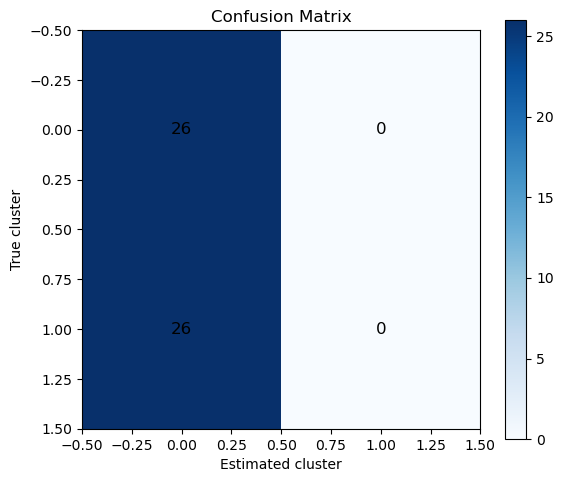

In [42]:
cm, aligned_est, mapping = aligned_confusion(true_clusters, z_est)

print("Cluster mapping:", mapping)
plot_confusion(cm)


Evaluacion series de tiempo

In [44]:
def plot_cluster_ndvi_posterior(trace, z_est, ci=0.9):
    """
    trace   : trace de PyMC
    z_est   : cluster asignado por serie
    """

    a_post = trace.posterior["a"].stack(sample=("chain","draw")).values
    # shape = (Kmax, N_segments, n_samples)

    clusters = np.unique(z_est)
    # bins = np.floor((days % 365) / 365 * n_segments).astype(int)

    plt.figure(figsize=(10,4))
    
    for k in clusters:

        samples = a_post[k, quincenas[:23], :]  # (365, n_samples)

        mean = samples.mean(axis=1)
        low  = np.percentile(samples, (1-ci)/2*100, axis=1)
        high = np.percentile(samples, (1+(ci))/2*100, axis=1)

        n_series = np.sum(z_est == k)

        plt.plot(quincenas[:23], mean, label=f"Cluster {k} (n={n_series})")
        plt.fill_between(quincenas[:23], low, high, alpha=0.25)

    # series reales
    # plt.plot(quincenas[:23], series[true_clusters, :23].mean(axis=0), color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas[:23], series[true_clusters == 1, :].T[:23], color='red', alpha=0.1)
    # plt.plot(quincenas[:23], series[true_clusters == 2, :].T[:23], color='blue', alpha=0.1)

    #Este anda!
    # plt.plot(quincenas, series[0::2, :23].mean(axis=0), linestyle=':', color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas, series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.1) #, label="Bosque medio"
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.1) #, label="No Bosque medio"

    plt.xlim(0, 23)
    plt.ylim(0.1, 0.6)

    plt.xlabel("Quincena")
    plt.ylabel("NDVI")
    plt.title("NDVI promedio por cluster (posterior PyMC)")
    plt.legend()
    plt.grid(True)
    plt.show()


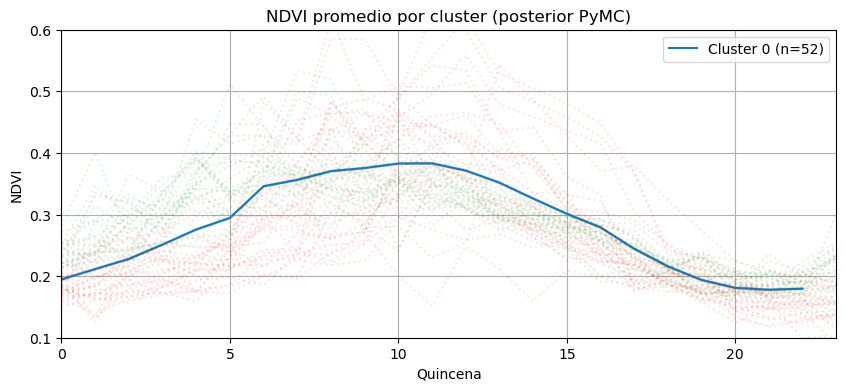

In [45]:
plot_cluster_ndvi_posterior(trace, z_est, ci=0.9)

In [ ]:
series[true_clusters, :23].mean(axis=0)

In [ ]:
series[1::2, :23].shape

In [ ]:
plt.plot(quincenas[:23], series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")


In [ ]:
quincenas.shape

In [ ]:
plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.5, label="Bosque medio")
plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.5, label="No Bosque medio")